## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Overview & Understanding
Objective:

To understand the structure, features, and basic characteristics of the dataset

In [2]:
df = pd.read_csv("superstore.csv")
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [3]:
df.shape

(51290, 27)

The dataset contains 51290 records with 27 features related to transactions, customers, and products, making it suitable for comprehensive business analysis.

In [4]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='str')

The dataset includes features related to orders, customers, products, sales, and geography.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  str    
 1   City            51290 non-null  str    
 2   Country         51290 non-null  str    
 3   Customer.ID     51290 non-null  str    
 4   Customer.Name   51290 non-null  str    
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  str    
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  str    
 9   Order.ID        51290 non-null  str    
 10  Order.Priority  51290 non-null  str    
 11  Product.ID      51290 non-null  str    
 12  Product.Name    51290 non-null  str    
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  str    
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null  int64  
 1

The dataset contains a mix of numerical and categorical variables. Date columns need to be converted into proper datetime format for time-based analysis.

In [6]:
df.describe()

,Discount,记录数,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


Sales and profit show variability, with some negative profit values indicating loss-making transactions.

In [7]:
df.isnull().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

Missing and duplicate values are not present in any columns.

#### “The dataset is well-structured with relevant features for sales, customer, and product analysis. Some preprocessing steps such as correcting columns, correcting data types, and removing unnecessary values or columns are required before proceeding to analysis.”

## Data Cleaning
Objective: 

To clean and prepare the dataset for accurate and reliable analysis

In [9]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace('.','_')
df.columns

Index(['category', 'city', 'country', 'customer_id', 'customer_name',
       'discount', 'market', '记录数', 'order_date', 'order_id', 'order_priority',
       'product_id', 'product_name', 'profit', 'quantity', 'region', 'row_id',
       'sales', 'segment', 'ship_date', 'ship_mode', 'shipping_cost', 'state',
       'sub_category', 'year', 'market2', 'weeknum'],
      dtype='str')

Column names were standardized to lowercase with underscores for consistency and easier handling.

In [10]:
column = [col for col in df.columns if df[col].nunique() == 1]
column

['记录数']

In [11]:
print(df['记录数'].value_counts())  

# this column has only 1 unique values so deleting this column
df.drop(columns = ['记录数'],inplace = True)

记录数
1    51290
Name: count, dtype: int64


Columns with no variance were removed as they do not contribute to analysis.

In [12]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

Date columns were converted into datetime format to enable time-based analysis.

### Feature Engineering

In [13]:
df['delivery_time'] = (df['ship_date']-df['order_date']).dt.days

In [14]:
df['profit_margin'] = df['profit']/df['sales']

New features like delivery time and profit margin were created to enhance analysis and extract deeper insights.

#### “The dataset was cleaned and preprocessed by standardizing column names, correcting Data Values, removing unnecessary Columns, and engineering new features. This ensures the data is consistent, reliable, and ready for exploratory analysis.”

## Key Performance Indicators (KPIs)

In [15]:
total_orders = df["order_id"].nunique()
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
avg_discount = df["discount"].mean()

top_customer = df.groupby(["customer_id","customer_name"])["sales"].sum().idxmax()
top_customer_sales = df.groupby(["customer_id","customer_name"])["sales"].sum().max()

print("Total Orders:", total_orders)
print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Average Discount:", round(avg_discount, 2))
print("Top Customer:", top_customer)
print("Top Customer Sales:", round(top_customer_sales, 2))

Total Orders: 25035
Total Sales: 12642905
Total Profit: 1467457.29
Average Discount: 0.14
Top Customer: ('SM-203204', 'Sean Miller')
Top Customer Sales: 25042


“The business generated total sales of 12642905 with an overall profit of 1467457.29 on total 25035 number of orders .The average discount is relatively high at 0.14, which may impact profitability. A significant portion of revenue is driven by top customers such as "Sean Miller", indicating dependency on high-value customers.”

## Univariate Analysis
Objective:

To analyze the distribution and characteristics of individual variables

### Sales Distribution

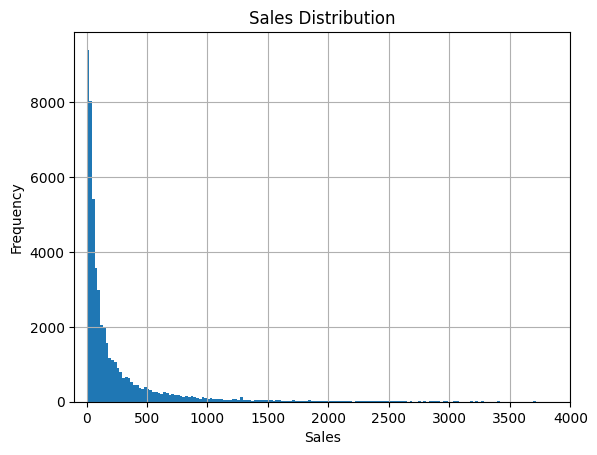

In [16]:
df['sales'].hist(bins = 1000)
plt.xlim(-100,4000)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

Sales are right-skewed, indicating that most transactions have low sales while a few transactions contribute very high revenue.

### Profit Distribution

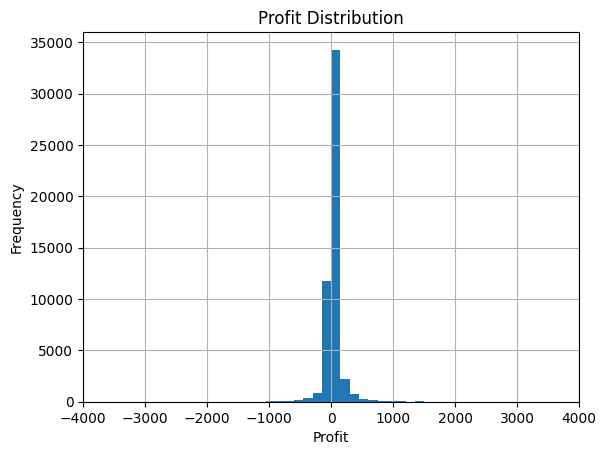

In [17]:
df['profit'].hist(bins = 100)
plt.xlim(-4000,4000)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

Profit distribution includes negative values, highlighting the presence of loss-making transactions.

### Category Count

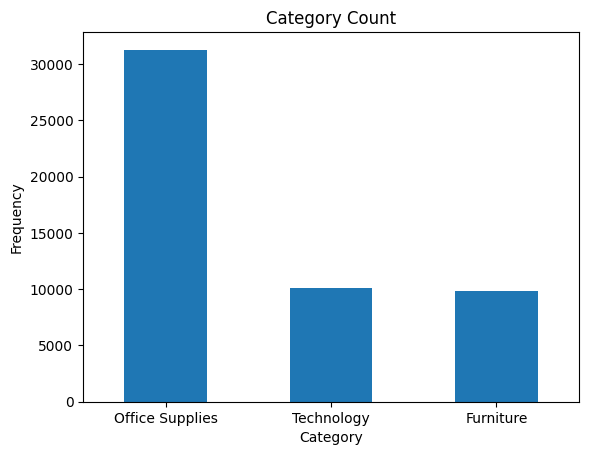

In [18]:
df['category'].value_counts().plot(kind = 'bar')
plt.title("Category Count")
plt.xlabel("Category")
plt.xticks(rotation = 0)
plt.ylabel("Frequency")
plt.show()

The dataset is dominated by certain categories, indicating uneven distribution of products.

### Sub Category Distribution

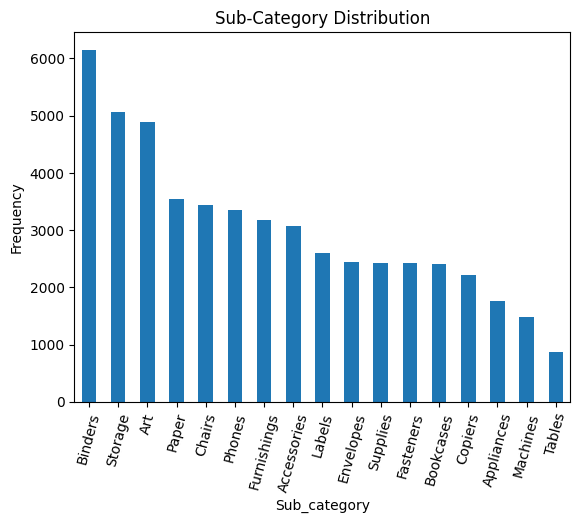

In [19]:
df['sub_category'].value_counts().plot(kind="bar")
plt.title("Sub-Category Distribution")
plt.xlabel("Sub_category")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.show()

Some sub-categories have significantly more transactions, which may influence overall sales and profit trends.

### Region Distribution

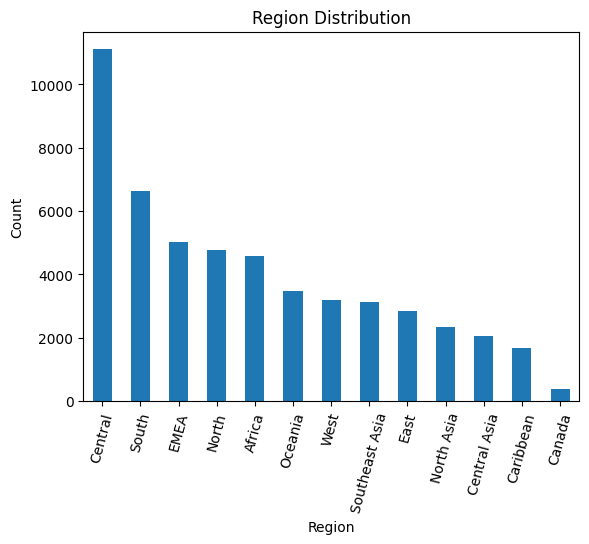

In [20]:
df["region"].value_counts().plot(kind="bar")
plt.title("Region Distribution")
plt.xlabel("Region")
plt.xticks(rotation = 75)
plt.ylabel("Count")
plt.show()

Transactions are spread across multiple regions, with certain regions having higher order volumes.

### Discount Distribution

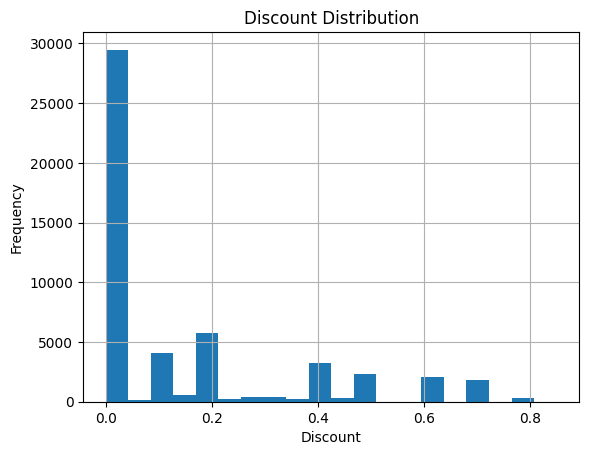

In [21]:
df["discount"].hist(bins=20)
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

Most transactions have low discounts, but some transactions involve very high discounts, which may impact profitability.

#### “Univariate analysis reveals that sales are highly skewed, profit includes negative values, and discount distribution indicates occasional high discounting. These patterns highlight potential areas for deeper analysis such as loss-making transactions and pricing strategies.”

## Bivariate Analysis
Objective:

To analyze relationships between different variables and identify key patterns

### Sales VS Profit 

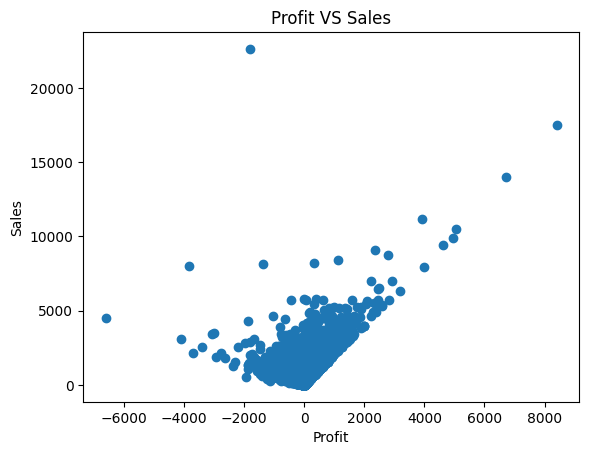

In [22]:
plt.scatter(df['profit'],df['sales'])
plt.xlabel("Profit")
plt.ylabel("Sales")
plt.title("Profit VS Sales")
plt.show()

While higher sales generally lead to higher profit, there are several cases where high sales still result in losses, indicating underlying issues like high discounts.

### Discount vs Profit

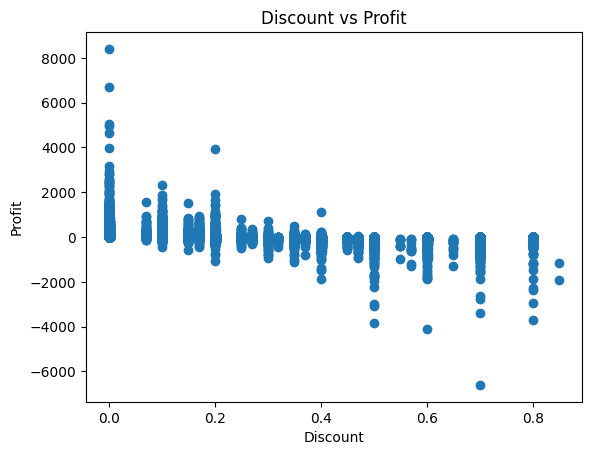

In [23]:
plt.scatter(df['discount'], df['profit'])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

There is a negative relationship between discount and profit, where higher discounts often lead to lower or negative profits.

### Category vs Sales

category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: sales, dtype: int64


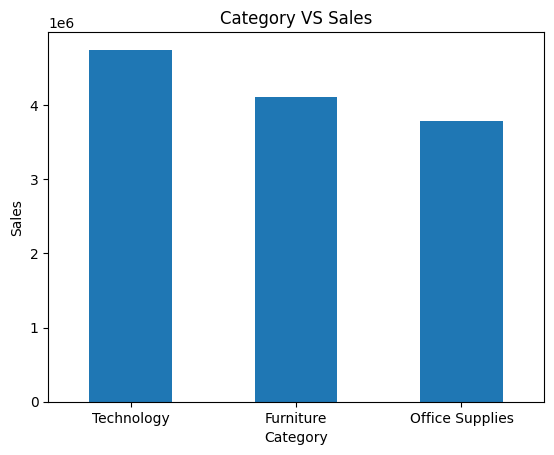

In [24]:
category_revenue = (
    df.groupby('category')['sales']
    .sum()
    .sort_values(ascending = False)
)
print(category_revenue)

category_revenue.plot(kind = 'bar')
plt.title("Category VS Sales")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.ylabel("Sales")
plt.show()

Certain categories contribute significantly more to total revenue, highlighting key business drivers.

### Category VS Profit

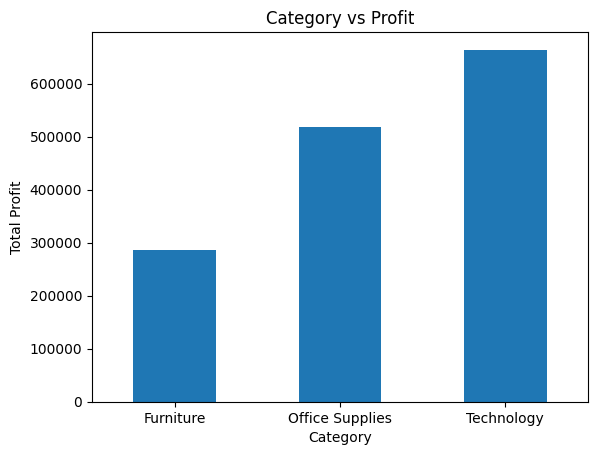

In [25]:
df.groupby("category")["profit"].sum().plot(kind="bar")
plt.title("Category vs Profit")
plt.xlabel("Category")
plt.xticks(rotation = 0)
plt.ylabel("Total Profit")
plt.show()

Some categories generate high sales but low or negative profit, indicating inefficiencies in pricing or cost structure.

#### “Bivariate analysis highlights key relationships such as the negative impact of discounts on profit, inconsistencies between sales and profitability, and variations across categories and regions. These insights help identify inefficiencies and opportunities for optimization.”

## Region Wise Analysis
Objective:

To analyze sales, profit, and efficiency across different regions and identify high-performing and underperforming markets

### Region wise Sales

In [26]:
region_sales = (
    df.groupby('region')['sales']
    .sum()
    .sort_values(ascending = False)
)
region_sales

region
Central           2822399
South             1600960
North             1248192
Oceania           1100207
Southeast Asia     884438
North Asia         848349
EMEA               806184
Africa             783776
Central Asia       752839
West               725514
East               678834
Caribbean          324281
Canada              66932
Name: sales, dtype: int64

Central region generates the highest revenue, indicating strong market demand and sales performance.

### Region wise Profit

In [27]:
region_profit = (
    df.groupby('region')['profit']
    .sum()
    .sort_values(ascending = False)
)
region_profit

region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           120089.11200
West              108418.44890
East               91522.78000
Africa             88871.63100
EMEA               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: profit, dtype: float64

Although some regions generate high sales, their profit is not equally high, indicating inefficiencies.

### Region Margin

In [28]:
region_margin = (
    df.groupby("region")["profit_margin"]
    .mean()
    .sort_values()
)
region_margin

region
Central               -inf
Africa           -0.145092
EMEA             -0.141618
Southeast Asia   -0.078870
South             0.053442
Caribbean         0.081182
Oceania           0.083502
North             0.125216
Central Asia      0.146987
East              0.167169
North Asia        0.179520
West              0.219441
Canada            0.247431
Name: profit_margin, dtype: float64

Regions with low profit margins despite high sales indicate poor pricing or high discounting strategies.

### Discount Analysis

In [29]:
region_discount = (
    df.groupby("region")["discount"]
    .mean()
    .sort_values(ascending=False)
)
region_discount

region
Southeast Asia    0.272077
EMEA              0.196083
Africa            0.156704
Oceania           0.153169
South             0.149050
East              0.145365
Central           0.138851
Caribbean         0.135751
West              0.109335
North             0.096056
Central Asia      0.067480
North Asia        0.048717
Canada            0.000000
Name: discount, dtype: float64

Regions with higher average discounts are more likely to experience lower profitability.

### Loss Contribution

In [30]:
loss_region = df[df["profit"] < 0].groupby("region")["profit"].sum().sort_values(ascending = True)

loss_region

region
Central          -202196.36690
South            -157234.74518
EMEA             -123065.91300
Southeast Asia    -89471.72840
Africa            -88875.03300
Oceania           -55973.18400
North             -52134.83996
East              -49590.60750
Central Asia      -29568.05100
North Asia        -25554.80100
Caribbean         -24259.92488
West              -22720.96090
Name: profit, dtype: float64

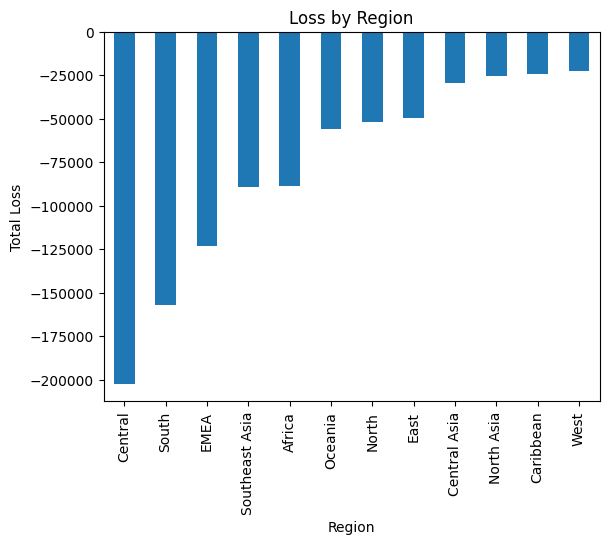

In [31]:
loss_region.plot(kind="bar")
plt.title("Loss by Region")
plt.xlabel("Region")
plt.ylabel("Total Loss")
plt.show()

Certain regions contribute more to overall losses, which require targeted strategies.

### Bottom VS Top Regions

In [32]:
region_profit.nlargest(2)
region_profit.nsmallest(2)

region
Canada            17817.390
Southeast Asia    17852.329
Name: profit, dtype: float64

A clear gap exists between top-performing and underperforming regions, highlighting uneven business performance.

#### “The Central region leads in sales, but profitability varies across regions. Some regions show low profit margins due to higher discounting, while others contribute significantly to losses. This indicates the need for region-specific pricing and discount strategies.”

## Product & Category Analysis
Objective:
 
To analyze product categories and sub-categories to identify top performers, loss-making areas, and pricing inefficiencies

### Category wise Sales and Profit

In [33]:
category_analysis = df.groupby("category")[["sales", "profit","profit_margin"]].sum()
category_analysis

,sales,profit,profit_margin
category,,,
Furniture,4110884,285204.72380,85.971690
Office Supplies,3787330,518473.83430,-inf
Technology,4744691,663778.73318,503.585678


Some categories generate high sales but do not translate into proportional profit.

### sub-Category profit

In [34]:
sub_cat_profit = (
    df.groupby('sub_category')['profit']
    .sum()
    .sort_values()
)
sub_cat_profit

sub_category
Tables         -64083.38870
Fasteners       11525.42410
Labels          15010.51200
Supplies        22583.26310
Envelopes       29601.11630
Furnishings     46967.42550
Art             57953.91090
Machines        58867.87300
Paper           59207.68270
Binders         72449.84600
Storage        108461.48980
Accessories    129626.30620
Chairs         140396.26750
Appliances     141680.58940
Bookcases      161924.41950
Phones         216717.00580
Copiers        258567.54818
Name: profit, dtype: float64

### Top VS Bottom Products

In [35]:
product_sales = df.groupby("product_name")["sales"].sum()

top_products = product_sales.nlargest(5)
bottom_products = product_sales.nsmallest(5)

top_products, bottom_products

(product_name
 Apple Smart Phone, Full Size             86936
 Cisco Smart Phone, Full Size             76441
 Motorola Smart Phone, Full Size          73159
 Nokia Smart Phone, Full Size             71904
 Canon imageCLASS 2200 Advanced Copier    61600
 Name: sales, dtype: int64,
 product_name
 Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    2
 Avery 5                                                             6
 Xerox 20                                                            6
 Grip Seal Envelopes                                                 7
 4009 Highlighters                                                   8
 Name: sales, dtype: int64)

A small number of products drive most of the revenue, while several products contribute minimally.

### Discount impact on category

In [36]:
category_discount = df.groupby("category")["discount"].mean()

category_discount

category
Furniture          0.168087
Office Supplies    0.137409
Technology         0.135342
Name: discount, dtype: float64

Furniture category has higher average discounts, which contributes to its low profitability.

### Loss Cocentration

In [37]:
loss_subcat = df[df["profit"] < 0].groupby("sub_category")["profit"].sum()

loss_subcat.sort_values().head(5)

sub_category
Tables      -144123.1486
Bookcases   -101446.2973
Phones       -96417.6601
Chairs       -96084.8969
Machines     -78672.7403
Name: profit, dtype: float64

Losses are concentrated in specific sub-categories rather than spread evenly.

#### “Product analysis reveals that while some categories generate strong revenue, profitability is highly uneven. Furniture category shows low profit margins due to higher discounting, with Tables and Bookcases being the major contributors to losses. Additionally, revenue is concentrated among a few high-performing products.”

## Customer Analysis
Objective:

To identify high-value customers, revenue concentration, and customer segmentation patterns

### Total Sales By Customer

In [38]:
total_sales = (
    df.groupby(['customer_id','customer_name'])['sales']
    .sum()
    .sort_values(ascending = False)
)
total_sales.head()

customer_id  customer_name
SM-203204    Sean Miller      25042
TC-209804    Tamara Chand     19050
CS-118451    Cari Sayre       16655
SP-209202    Susan Pistek     16566
VG-218051    Vivek Grady      15654
Name: sales, dtype: int64

A small number of customers contribute significantly to total revenue.

### Top VS Bottom Customers

In [39]:
top_customers = total_sales.nlargest(5)
bottom_customers = total_sales.nsmallest(5)
print(top_customers)
print("-"*70)
print("-"*70)
print(bottom_customers)

customer_id  customer_name
SM-203204    Sean Miller      25042
TC-209804    Tamara Chand     19050
CS-118451    Cari Sayre       16655
SP-209202    Susan Pistek     16566
VG-218051    Vivek Grady      15654
Name: sales, dtype: int64
----------------------------------------------------------------------
----------------------------------------------------------------------
customer_id  customer_name      
AH-1202      Adrian Hane            2
CK-22051     Chloris Kastensmidt    3
BS-17552     Bruce Stewart          3
LH-70202     Lisa Hazard            4
LP-70951     Liz Preis              4
Name: sales, dtype: int64


There is a large gap between top and low-value customers, indicating uneven revenue distribution.

### Revenue Concentration

In [40]:
top_10_pct = int(len(total_sales)*0.1)
top_revenue = total_sales.head(top_10_pct).sum()
total_revenue = total_sales.sum()

revenue_pct = top_revenue/total_revenue
print(revenue_pct)

0.31257222924636385


A small percentage of customers contribute a large portion of revenue (Pareto Principle).

### Segment wise Analysis

In [41]:
segment_analysis = df.groupby(['segment'])[['sales','profit']].sum()
segment_analysis

,sales,profit
segment,,
Consumer,6508141,749239.78206
Corporate,3824808,441208.32866
Home Office,2309956,277009.18056


Certain customer segments generate higher profit, indicating better business opportunities.

### Profitability by Customers

In [42]:
Customer_profit = df.groupby(['customer_id','customer_name'])['profit'].sum().sort_values(ascending = False)
Customer_profit.head(5)

customer_id  customer_name
TC-209804    Tamara Chand     8981.3239
RB-193604    Raymond Buch     6976.0959
SC-200954    Sanjit Chand     5757.4119
HL-150404    Hunter Lopez     5622.4292
AB-101054    Adrian Barton    5444.8055
Name: profit, dtype: float64

Some customers generate losses despite contributing to sales, indicating inefficiencies.

### Regular Customers

In [43]:
Regular = df[['customer_id','customer_name']].value_counts()
Regular.head(10)

customer_id  customer_name  
JG-158051    John Grady         40
WB-218504    William Brown      37
BC-111252    Becky Castell      37
AF-108701    Art Ferguson       36
BW-111101    Bart Watters       35
JG-158052    John Grady         35
NH-186101    Nicole Hansen      35
CS-121751    Charles Sheldon    35
MA-175604    Matt Abelman       34
JL-158354    John Lee           34
Name: count, dtype: int64

Frequent buyers can be targeted for loyalty programs.

#### “Customer analysis shows that revenue is highly concentrated among a small group of high-value customers. Additionally, certain customers contribute to losses, indicating the need for better targeting and pricing strategies. Segment-wise analysis highlights opportunities to focus on more profitable customer groups.”

## Loss Analysis
Objective:

To identify Loss Category, Sub Category and reson behind Loss.

In [44]:
## Creating a Loss DataFrame For Analysis
loss_data = df[df['profit']<0]
loss_data.head(5)

,category,city,country,customer_id,customer_name,discount,market,order_date,order_id,order_priority,...,ship_date,ship_mode,shipping_cost,state,sub_category,year,market2,weeknum,delivery_time,profit_margin
29009,Technology,Paris,France,RC-198252,Roy Collins,0.15,EU,2011-04-26,IT-2011-2185983,Critical,...,2011-04-27,Same Day,100.32,Ile-de-France,Phones,2011,EU,18,1,-0.035485
29012,Technology,Taverny,France,TB-211752,Thomas Boland,0.15,EU,2011-08-26,ES-2011-5235241,High,...,2011-08-27,Same Day,70.11,Ile-de-France,Copiers,2011,EU,35,1,-0.035348
29018,Technology,Tremblay-en-France,France,DH-130752,Dave Hallsten,0.15,EU,2011-12-02,ES-2011-4614329,High,...,2011-12-04,First Class,5.53,Ile-de-France,Machines,2011,EU,49,2,-0.000521
29021,Technology,Guyancourt,France,MH-174552,Mark Hamilton,0.15,EU,2012-06-07,ES-2012-2141914,High,...,2012-06-11,Second Class,60.78,Ile-de-France,Phones,2012,EU,23,4,-0.023622
29024,Technology,Le Plessis-Robinson,France,AA-104802,Andrew Allen,0.15,EU,2012-08-30,IT-2012-5602177,Medium,...,2012-09-02,Second Class,111.55,Ile-de-France,Copiers,2012,EU,35,3,-0.058870


In [45]:
## Category Wise Loss Analysis
loss_by_category = (
    loss_data.groupby('category')['profit']
    .sum()
    .reset_index()
    .sort_values(by = 'profit')
)

loss_by_category

,category,profit
0,Furniture,-370168.83970
2,Technology,-286495.39842
1,Office Supplies,-263981.91760


In [46]:
## Sub Category Wise Loss Analysis
loss_by_subcategory = (
    loss_data.groupby('sub_category')['profit']
    .sum()
    .reset_index()
    .sort_values(by = 'profit')
)

loss_by_subcategory

,sub_category,profit
16,Tables,-144123.14860
4,Bookcases,-101446.29730
13,Phones,-96417.66010
5,Chairs,-96084.89690
11,Machines,-78672.74030
14,Storage,-76063.97800
6,Copiers,-71547.49982
1,Appliances,-63991.69040
3,Binders,-52884.06130
0,Accessories,-39857.49820


In [47]:
# Discount VS Profit Analysis 
df[df['profit']<0][['category','sub_category','discount','profit','sales']].head(10)

,category,sub_category,discount,profit,sales
29009,Technology,Phones,0.15,-24.2715,684
29012,Technology,Copiers,0.15,-19.0170,538
29018,Technology,Machines,0.15,-0.0495,95
29021,Technology,Phones,0.15,-6.7560,286
29024,Technology,Copiers,0.15,-111.4995,1894
29026,Technology,Machines,0.15,-74.7930,454
29028,Technology,Copiers,0.15,-53.5290,1136
29029,Technology,Machines,0.15,-0.0540,2017
29038,Technology,Copiers,0.15,-28.4940,242
29039,Technology,Phones,0.15,-0.1200,779


In [48]:
# High discounts are the key driver of the losses
loss_discounts = df[df['profit']<0]['discount'].mean()
profit_discounts = df[df['profit']>0]['discount'].mean()
print("Loss Discounts =",loss_discounts)
print("Profit Discounts =",profit_discounts)

Loss Discounts = 0.450811862244898
Profit Discounts = 0.04332039497872787


#### “There is a strong correlation between high discounts and losses. Loss-making transactions have an average discount of ~45%, compared to only ~4% in profitable cases. This indicates that excessive discounting is a major reason for losses, especially in Furniture sub-categories like Tables and Bookcases.”

#### “The company should reduce excessive discounts or optimize pricing strategies in Furniture category to improve profitability.”

## CONCLUSION 

“This analysis explored sales, profitability, customer behavior, and regional performance of the business. The Central region emerged as the highest revenue-generating region, while profitability varied across regions due to differences in discount strategies.

Product-level analysis revealed that although some categories drive strong sales, profitability is uneven. The Furniture category, particularly Tables and Bookcases, contributes significantly to overall losses.

A key finding is that high discounts are strongly correlated with losses, with loss-making transactions having significantly higher average discounts compared to profitable ones.

Customer analysis showed that revenue is moderately concentrated, with the top 10% of customers contributing approximately 31% of total revenue. Additionally, no major loss-making customers were identified, indicating that losses are more product-driven rather than customer-driven.

Overall, the analysis highlights inefficiencies in pricing and discount strategies rather than demand issues.”

## BUSINESS RECOMMENDATIONS

### 1. Optimize Discount Strategy

“Reduce excessive discounting, especially in Furniture category, as high discounts are directly linked to losses.”

### 2. Focus on Loss-Making Sub-Categories

“Re-evaluate pricing and cost structure for Tables and Bookcases to minimize losses.”

### 3. Region-Specific Strategy

“Implement region-wise pricing and discount strategies, as profitability varies significantly across regions.”

### 4. Retain High-Value Customers

“Develop loyalty programs for top customers who contribute a significant portion of revenue.”

### 5. Improve Profit Margins

“Focus on high-margin categories and optimize operations in low-margin categories to improve overall profitability.”

### 6. Monitor High Discount Transactions

“Introduce controls or thresholds on discount levels to prevent excessive loss-making transactions.”
